In [4]:
import matplotlib.pyplot as plt
import numpy as np
import time

In [5]:
# ==========================================
# 1. 데이터 생성 모듈
# ==========================================
def generate_virtual_data(T, K, M, noise_level):
    
    """
    기준 시계열 (Reference, Y) 생성
    """
    # 16개의 채널이 서로 다른 주파수와 위상 패턴을 갖도록 생성
    time_steps = np.linspace(0, 20, T) # 0부터 20까지 T개의 시간 단계 생성
    Y = np.zeros((T, K)) # 기준 시계열 행렬 (T x K)
    for k in range(K): # 각 채널마다 다른 패턴 생성
        # 채널 k는 주파수와 위상이 k에 따라 달라지는 사인과 코사인 패턴을 가짐
        Y[:, k] = np.sin(time_steps * (0.5 + 0.1 * k)) + np.cos(time_steps * (0.2 * k))

    # # 생성된 시계열 시각화
    # plt.figure(figsize=(12, 6))
    # for k in range(K):
    #     plt.plot(time_steps, Y[:, k] + k * 5, label=f'Channel {k+1}')  # 채널 간 시각적 구분을 위해 오프셋 추가
    # plt.title('Reference Time Series (Y)')
    # plt.xlabel('Time')
    # plt.ylabel('Value (with offset)')
    # plt.legend(loc='upper right')
    # plt.show()

    """
    # 소스 시계열 (Sources, X) 생성 및 채널 섞기
    """
    X = np.zeros((M, T, K))  # M개의 소스 시계열을 저장할 3D 배열 (M x T x K)
    ground_truth_perms = []  # 각 소스별 실제 적용된 채널 순열 (우리가 맞춰야 할 정답)

    for m in range(M):
        # 기준 시계열 Y에 가우시안 노이즈를 추가하여 소스 시계열 생성
        noisy_source = Y + np.random.normal(0, noise_level, (T, K))
        # 각 소스 시계열마다 K개의 채널을 무작위로 섞음 (채널 순서가 달라짐)
        perm = np.random.permutation(K)  # 예: [3, 15, 0, 1, ...]
        ground_truth_perms.append(perm.tolist())
        X[m] = noisy_source[:, perm]     # 채널 섞기

    print(f"탐색 공간 크기: ( {K}! ) ^ {M} = 무한대에 가까운 NP-hard 문제")
    
    return Y, X, ground_truth_perms

In [38]:
# ==========================================
# 2. 유틸리티 함수
# ==========================================
def calculate_similarity(candidate_perms, Y, X):  # 목적 함수
    """
    제안된 순열 조합(candidate_perms)을 X에 적용하여 재배열한 뒤,
    평균을 내어 기준 시계열 Y와의 평균 피어슨 상관계수를 계산합니다.
    """
    # 1. 소스 데이터 재배열 및 집계 (논문 식 2)
    X_rearranged = np.zeros_like(X)  # 재배열된 소스 시계열을 저장할 배열 (M x T x K)
    for m in range(M):  # 각 소스 시계열마다 제안된 순열을 적용하여 채널을 재배열
        # 후보 순열의 역순열(Inverse permutation)을 구해서 원래 자리로 되돌림
        inv_perm = np.argsort(candidate_perms[m])
        X_rearranged[m] = X[m][:, inv_perm]
    
    # M개의 재배열된 소스 시계열의 평균을 내어 Y_hat 생성
    Y_hat = np.mean(X_rearranged, axis=0) 
    
    # 2. 채널별 피어슨 상관계수 계산 및 평균 
    corr_sum = 0
    for k in range(K): # 각 채널마다 Y와 Y_hat의 피어슨 상관계수를 계산하여 누적
        corr_matrix = np.corrcoef(Y[:, k], Y_hat[:, k]) 
        corr_sum += corr_matrix[0, 1]
        
    return corr_sum / K


def evaluate_accuracy(predicted_perms, ground_truth_perms):  # 정확도 측정
    """
    알고리즘이 추정한 순열(predicted_perms)과 실제 정답 순열(ground_truth_perms)을 비교하여
    전체 채널 중 올바른 위치를 찾아낸 채널의 비율(%)을 계산합니다.
    
    :param predicted_perms: 알고리즘이 예측한 소스별 채널 순열 (크기: M x K)
    :param ground_truth_perms: 실제 섞을 때 사용한 정답 채널 순열 (크기: M x K)
    :return: 채널 정렬 정확도 (Accuracy, 0.0 ~ 100.0)
    """
    # 리스트 형태의 입력을 원소별(element-wise) 비교가 가능한 numpy 배열로 변환
    pred_arr = np.array(predicted_perms)
    true_arr = np.array(ground_truth_perms)
    
    # 전체 평가 대상 채널의 총 개수 (M * K)
    total_channels = pred_arr.size
    
    # 예측된 인덱스와 실제 정답 인덱스가 정확히 일치하는 개수를 계산
    correct_channels = np.sum(pred_arr == true_arr)
    
    # 백분율(%)로 변환
    accuracy = (correct_channels / total_channels) * 100.0
    
    return accuracy


def print_results_table(results):  # 성능평가 결과 출력
    """
    여러 탐색 알고리즘의 실험 결과 딕셔너리를 입력받아
    가독성 높은 텍스트 표(Table) 형태로 출력합니다.
    
    :param results: 형태 -> {"알고리즘 이름": {"Accuracy": 98.5, "Correlation": 0.95...}, ...}
    """
    # 표의 너비 설정
    table_width = 65
    
    # 상단 테두리 및 제목
    print("\n" + "=" * table_width)
    print(f"{'🚀 실험 결과 요약 (Experimental Results)':^{table_width}}")
    print("=" * table_width)
    
    # 헤더(Header) 출력 (좌측 정렬 25칸, 중앙/우측 정렬 15칸씩 할당)
    print(f"{'Method (Algorithm)':<25} | {'Accuracy (%)':^15} | {'Final Corr (r)':^15}")
    print("-" * table_width)
    
    # 데이터 행(Row) 출력
    for method_name, metrics in results.items():
        # 딕셔너리에서 값 추출 (값이 없을 경우 기본값 0.0 적용)
        acc = metrics.get("Accuracy", 0.0)
        corr = metrics.get("Correlation", 0.0)
        
        # Method는 좌측 정렬(<), 숫자는 소수점 고정 및 우측 정렬(>)
        print(f"{method_name:<25} | {acc:>13.2f} % | {corr:>14.4f}")
        
    # 하단 테두리
    print("=" * table_width + "\n")


def plot_convergence_trend(history_dict):
    """
    알고리즘별 탐색 횟수(예산)에 따른 최고 상관계수의 수렴 추세를 시각화합니다.
    """
    plt.figure(figsize=(10, 6))
    
    # 선 스타일과 색상을 다양하게 지정하여 가독성 확보
    styles = ['-', '--', '-.', ':']
    
    for (name, history), style in zip(history_dict.items(), styles):
        if name == "Baseline (No Search)":
            continue

        # x축은 탐색 횟수(1부터 budget까지), y축은 기록된 상관계수
        iterations = range(1, len(history) + 1)
        plt.plot(iterations, history, label=name, linestyle=style, linewidth=2)
        
    # 그래프 꾸미기 (논문 퀄리티 포맷팅)
    plt.title('Convergence Trend of Permutation Optimization Algorithms', fontsize=14, fontweight='bold')
    plt.xlabel('Number of Computations (Budget)', fontsize=12)
    plt.ylabel('Best Pearson Correlation (r)', fontsize=12)
    
    # y축 범위를 명확히 하여 차이가 잘 보이게 설정 (필요시 조정 가능)
    # plt.ylim(0.0, 1.05) 
    
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(loc='lower right', fontsize=11)
    plt.tight_layout()
    
    # 그래프 출력 및 논문 삽입용 파일로 저장
    plt.savefig('convergence_trend.png', dpi=300)
    plt.show()

In [39]:
# ==========================================
# 3. 순열 탐색 알고리즘
# ==========================================
def baseline_search(Y, X, budget):
    """
    베이스라인 (Baseline) 모델:
    어떠한 최적화 탐색도 수행하지 않고, 현재 섞여 있는 채널 상태 그대로 
    기준 시계열과의 유사도를 측정합니다. 
    논문 상의 P = {1, 1, ..., 1} (초기 배열 상태)에 해당합니다.
    """
    M, T, K = X.shape  # X의 차원(Shape)으로부터 M과 K를 동적으로 가져옴
    
    # 어떠한 채널 변경도 수행하지 않는 기본 순열 [0, 1, 2, ..., K-1] 생성
    # 이를 M개의 소스 전체에 동일하게 할당함
    baseline_perms = [list(range(K)) for _ in range(M)]
    
    # 섞인 상태 그대로 목적 함수(상관계수)를 단 1회 계산
    corr = calculate_similarity(baseline_perms, Y, X)
    
    # 예산(budget)을 소진하지 않으므로, 계산된 1회의 결과만 반환
    return baseline_perms, corr, _


def random_search(Y, X, budget):  # 무작위 탐색
    best_corr = -1.0
    best_perms = None
    corr_history = []  # 탐색 기록을 저장할 리스트
    
    for i in range(budget):
        random_perms = [np.random.permutation(K).tolist() for _ in range(M)]
        corr = calculate_similarity(random_perms, Y, X)
        
        # 현재 조합의 상관계수가 지금까지 본 최고 상관계수보다 높으면 갱신
        if corr > best_corr:
            best_corr = corr
            best_perms = random_perms
        
        corr_history.append(best_corr)  # 매 탐색마다 최고 기록 저장
    
    return best_perms, best_corr, corr_history


def sahc_search(Y, X, budget):
    """
    Steepest Ascent Hill Climbing (SAHC) 알고리즘
    매 스텝마다 가능한 이웃(Neighbor)을 모두 평가한 후, 가장 성능 향상이 큰 해로 이동합니다.
    """
    # 1. 초기 해 무작위 생성 및 평가
    current_perms = [np.random.permutation(K).tolist() for _ in range(M)]
    current_corr = calculate_similarity(current_perms, Y, X)
    
    evals = 1 # 예산 소진 카운트
    best_overall_corr = current_corr  # 전체 탐색 과정에서의 최고 기록
    corr_history = [best_overall_corr]
    
    # 2. 예산이 남아있는 동안 탐색 반복
    while evals < budget:
        best_neighbor_perms = None
        best_neighbor_corr = -1.0
        
        # [이웃(Neighborhood) 생성 및 평가]
        # 탐색 공간(16!)이 너무 크므로, 무작위로 타겟 소스(m)를 하나 선택한 뒤,
        # 해당 소스 내에서 2개의 채널 위치를 맞바꾸는(Swap) 모든 조합(16C2 = 120개)을 이웃으로 정의합니다.
        target_m = np.random.randint(M)
        
        # 120개의 이웃을 모두 평가 (Steepest Ascent의 핵심)
        for i in range(K):
            for j in range(i + 1, K):
                if evals >= budget: 
                    break # 예산 초과 시 즉시 중단
                
                # 이웃 생성: 현재 순열을 복사한 뒤 타겟 m의 i, j 채널 스왑
                neighbor_perms = [list(p) for p in current_perms]
                neighbor_perms[target_m][i], neighbor_perms[target_m][j] = neighbor_perms[target_m][j], neighbor_perms[target_m][i]
                
                # 이웃 유사도 평가
                corr = calculate_similarity(neighbor_perms, Y, X)
                evals += 1
                
                # 평가된 이웃 중 가장 높은 성능을 기록
                if corr > best_neighbor_corr:
                    best_neighbor_corr = corr
                    best_neighbor_perms = neighbor_perms

                # 전체 최고 기록 갱신 여부 확인
                if corr > best_overall_corr:
                    best_overall_corr = corr

                corr_history.append(best_overall_corr)  # 매 평가마다 전체 최고 기록 저장
        
        if evals >= budget:
            break
            
        # 3. 언덕 오르기 (Hill Climbing) 조건 검사
        # 탐색된 최고 성능의 이웃이 현재 상태보다 우수하다면 해당 위치로 이동합니다.
        if best_neighbor_corr > current_corr:
            current_perms = best_neighbor_perms
            current_corr = best_neighbor_corr
        else:
            # 지역 최적해(Local Optima)에 도달하여 성능 향상이 없다면, 
            # 루프를 계속 진행하여 다음 타겟(m) 주변을 탐색하도록 유도합니다.
            continue
            
    return current_perms, current_corr, corr_history

In [40]:
# ==========================================
# 4. 메인 실행부 (실험 통제 및 결과 기록)
# ==========================================
if __name__ == "__main__":
    # 1. 공통 데이터 준비
    T = 1000            # 시계열 길이
    K = 16              # 채널 수 (경우의 수: 16! ≒ 20조 개)
    M = 30              # 소스 시계열 수 (센서 노드 또는 에이전트 수)
    noise_level = 0.5   # 가우시안 노이즈 강도 (SNR 조절용)
    np.random.seed(42)  # 실험 재현성을 위한 시드 고정

    Y, X, ground_truth = generate_virtual_data(T, K, M, noise_level=0.5)
    BUDGET = 20000 # 동일한 연산 예산 부여

    # 2. 알고리즘 리스트업
    algorithms = {
        "Baseline (No Search)": baseline_search,
        "Random Search": random_search,
        "SAHC": sahc_search
    }

    # 3. 알고리즘 평가
    results = {}
    history_records = {}  # 그래프를 그리기 위한 기록장 딕셔너리

    for name, algo_func in algorithms.items():
        start_time = time.time()
        print(f"\n[{name}] 실험 시작...")

        # 알고리즘 실행
        best_perms, corr, history = algo_func(Y, X, BUDGET)

        # 정확도(accuracy) 및 성능 평가 로직
        accuracy = evaluate_accuracy(best_perms, ground_truth)

        # 결과 저장
        results[name] = {"Accuracy": accuracy, "Correlation": corr}
        history_records[name] = history
        
        elapsed_time = time.time() - start_time
        print(f"탐색 횟수: {BUDGET} 회")
        print(f"소요 시간: {elapsed_time:.2f} 초")
        print(f"최종 상관계수 (r): {corr:.4f}")
        print(f"채널 정렬 정확도 (Accuracy): {accuracy:.2f}%")
    
    # 최종 결과 출력 (논문의 Table 형태로 출력)
    print_results_table(results)

탐색 공간 크기: ( 16! ) ^ 30 = 무한대에 가까운 NP-hard 문제

[Baseline (No Search)] 실험 시작...
탐색 횟수: 20000 회
소요 시간: 0.01 초
최종 상관계수 (r): 0.2712
채널 정렬 정확도 (Accuracy): 6.46%

[Random Search] 실험 시작...
탐색 횟수: 20000 회
소요 시간: 64.92 초
최종 상관계수 (r): 0.4051
채널 정렬 정확도 (Accuracy): 9.79%

[SAHC] 실험 시작...
탐색 횟수: 20000 회
소요 시간: 68.67 초
최종 상관계수 (r): 0.9388
채널 정렬 정확도 (Accuracy): 48.75%

                🚀 실험 결과 요약 (Experimental Results)                
Method (Algorithm)        |  Accuracy (%)   | Final Corr (r) 
-----------------------------------------------------------------
Baseline (No Search)      |          6.46 % |         0.2712
Random Search             |          9.79 % |         0.4051
SAHC                      |         48.75 % |         0.9388



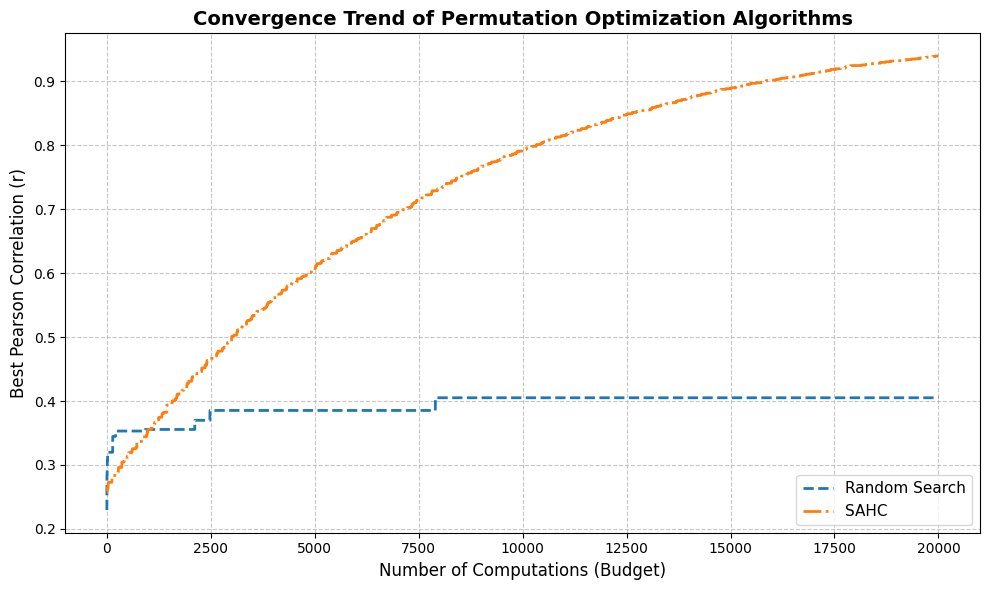

In [41]:
# 수렴 추세 시각화 함수 호출
plot_convergence_trend(history_records)